In [24]:
import numpy as np
import scipy
import utils
import pandas as pd
import regionmask
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs

In [ ]:
def get_atm_center(ds_atm, sfc_center):

    ds_atm = ds_atm.sel(latitude = slice(sfc_center['center_lat'].values - 2, sfc_center['center_lat'].values + 2),
                        longitude = slice(sfc_center['center_lon'].values - 2, sfc_center['center_lon'] + 2))
    
    
    if ds_atm['gh'].isnull().any():
        print('NaN values within area of interest. Skipping Frame')
        try:
            ds_atm['gh'].plot()
            plt.show()
        except Exception as e:
            print(e)    
        return None
    land_mask = regionmask.defined_regions.ar6.land.mask(ds_atm.longitude, ds_atm.latitude)

    if (land_mask == 1).any():
        print('Land within area of interest. Skipping Frame')
        land_mask.plot()
        return None
    
    hgt_threshold = np.quantile(ds_atm['gh'], 0.01)
    hgt_clusters = ds_atm['gh'].where(ds_atm['gh'] < hgt_threshold)
    ght_clusters_mask = ~hgt_clusters.isnull()

    clusters = scipy.ndimage.label(ght_clusters_mask)
    cluster_size = []
    for a in np.arange(clusters[1]):
        cluster_number = a + 1
        cluster_size.append(np.sum(np.where(clusters[0] == cluster_number, 1, 0)))

    
    largest_cluster = np.argmax(cluster_size) + 1
    center_y, center_x = scipy.ndimage.center_of_mass(clusters[0], largest_cluster)
    mslp = ds_atm['gh'].where(clusters[0] == largest_cluster).min().values

    center_lat = ds_atm.latitude.isel(latitude =int(np.round(center_y)))
    center_lon = ds_atm.longitude.isel(longitude =int(np.round(center_x)))
    
    center_info = dict(center_lat = center_lat, center_lon = center_lon, mslp = mslp)
    return center_info

# def get_sfc_center(ds):
#     min_pressure = ds['prmsl'].min().values

#     ## Threshold is just based on the lowest mslp within the frame
#     ## Given that the calculated center is the center of mass for 
#     ## the largest contingous 1% low pressure area, final center
#     ## pressure and lowest pressure in the frame may not be exactly
#     ## the same.
#     if min_pressure > 1005: # Pressure threshold (pa) 1005mb
#         print(f'{min_pressure}mb is over the pressure threshold')
#         return None
#     nan_mask = ds['prmsl'].isnull()
#     ds_sfc = ds.where(~nan_mask, drop = True).isel(latitude = slice(50,-50), longitude = slice(50,-50))
    

#     slp_threshold = np.quantile(ds_sfc['prmsl'], 0.01)
#     slp_clusters = ds_sfc['prmsl'].where(ds_sfc['prmsl'] < slp_threshold)
#     slp_clusters_mask = ~slp_clusters.isnull()

#     clusters = scipy.ndimage.label(slp_clusters_mask)
#     cluster_size = []
#     for a in np.arange(clusters[1]):
#         cluster_number = a + 1
#         cluster_size.append(np.sum(np.where(clusters[0] == cluster_number, 1, 0)))

    
#     largest_cluster = np.argmax(cluster_size) + 1
#     center_y, center_x = scipy.ndimage.center_of_mass(clusters[0], largest_cluster)
#     mslp = ds_sfc['prmsl'].where(clusters[0] == largest_cluster).min()

#     center_lat = ds_sfc.latitude.isel(latitude =int(np.round(center_y)))
#     center_lon = ds_sfc.longitude.isel(longitude =int(np.round(center_x)))
    
#     center_info = dict(center_lat = center_lat, center_lon = center_lon, mslp = mslp)
#     return center_info

def random_link_selection(num_of_frames, links_path):
    result = []
    with open(links_path) as f:
        links = pd.read_csv(f)
    random_frames = links.sample(num_of_frames)
    for link in random_frames.values:
        result.append(('https://noaa-nws-hafs-pds.s3.amazonaws.com/' + link).squeeze())
    
    return result
    

In [ ]:
atm_args = dict(typeOfKey = 'isobaricInhPa',filename="Model_Data/temp_gribs/atm_temp.grib2" )
sfc_args = dict(typeOfKey = 'meanSea',filename="Model_Data/temp_gribs/sfc_temp.grb2" )

In [29]:
random_links = random_link_selection(8, 'Model_Data\links\link_list.txt')

<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\12ian\AppData\Local\Temp\ipykernel_4732\925719778.py:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  random_links = random_link_selection(8, 'Model_Data\links\link_list.txt')


Ignoring index file 'Model_Data/temp_gribs/sfc_temp.grb2.5b7b6.idx' older than GRIB file


1003.5700073242188mb is below the pressure threshold of 1005mb


c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cartopy\mpl\geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


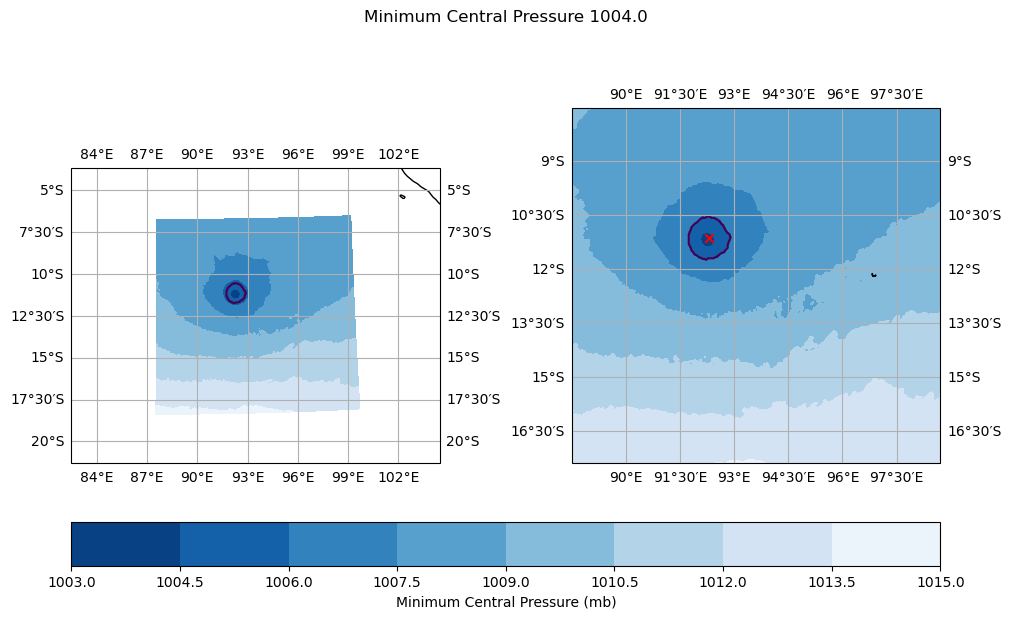

Ignoring index file 'Model_Data/temp_gribs/atm_temp.grib2.5b7b6.idx' older than GRIB file
skipping variable: paramId==3017 shortName='dpt'
Traceback (most recent call last):
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  825.,  800.,
        775.,  750.,  725.,  700.,  675.,  650.,  625.,  600.,  575.,
        550.,  525.,  500.,  475.,  450.,  425.,  400.,  375.,  350.,
        325.,  300.,  275.,  250.,  225.,  200.,  175.,  150.,  125.,
        100.,   70.,   50.

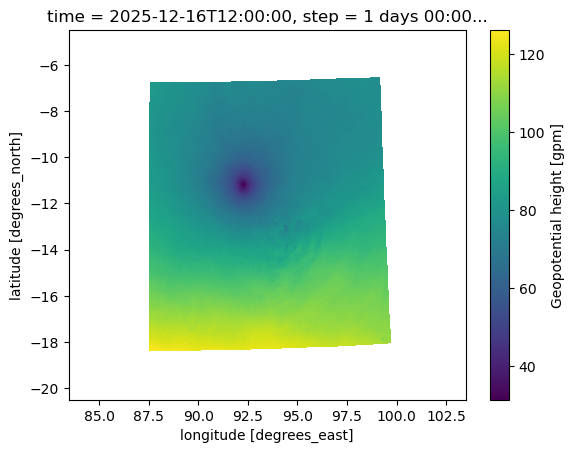

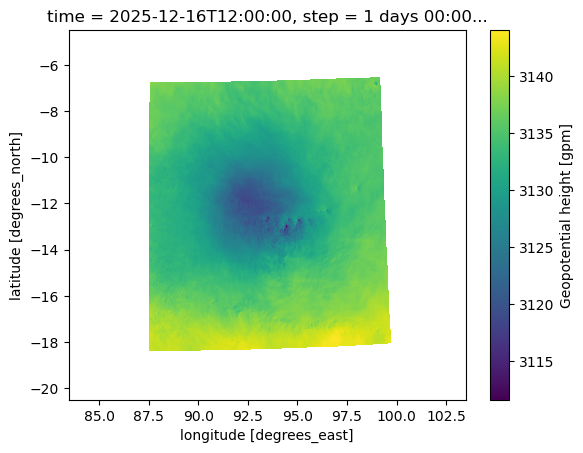

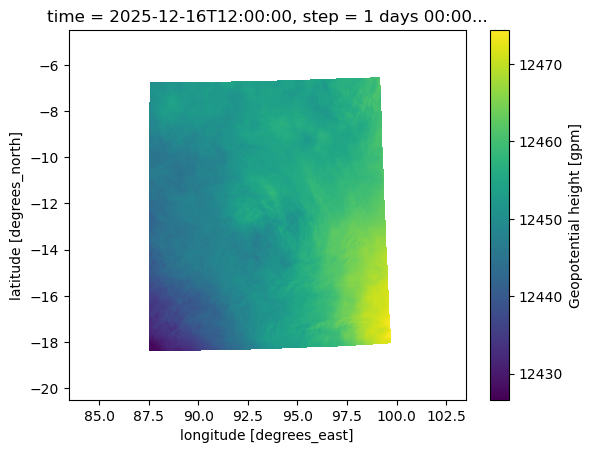

Ignoring index file 'Model_Data/temp_gribs/sfc_temp.grb2.5b7b6.idx' older than GRIB file


966.510009765625mb is below the pressure threshold of 1005mb


c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cartopy\mpl\geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


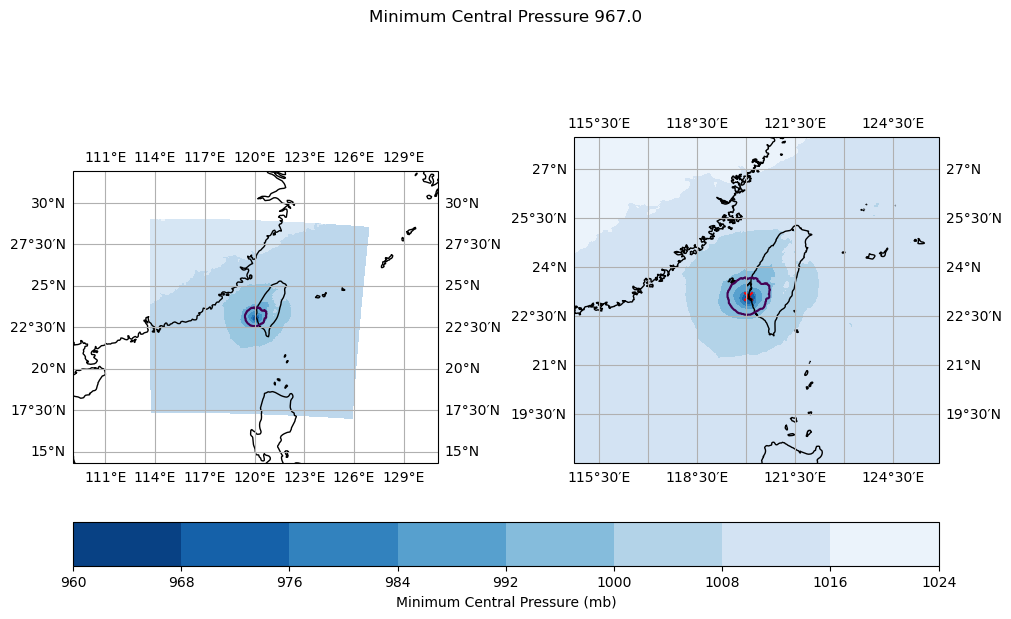

Ignoring index file 'Model_Data/temp_gribs/atm_temp.grib2.5b7b6.idx' older than GRIB file
skipping variable: paramId==3017 shortName='dpt'
Traceback (most recent call last):
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  825.,  800.,
        775.,  750.,  725.,  700.,  675.,  650.,  625.,  600.,  575.,
        550.,  525.,  500.,  475.,  450.,  425.,  400.,  375.,  350.,
        325.,  300.,  275.,  250.,  225.,  200.,  175.,  150.,  125.,
        100.,   70.,   50.

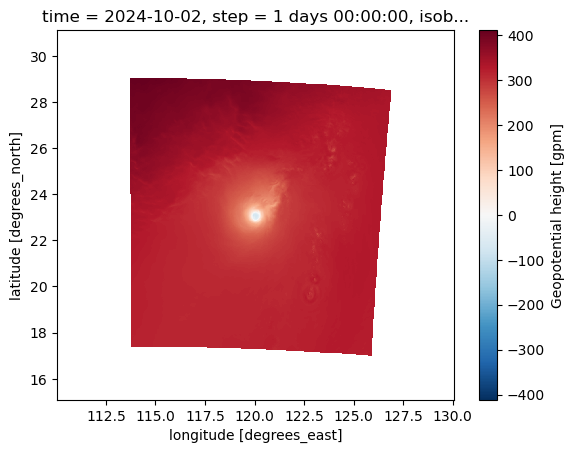

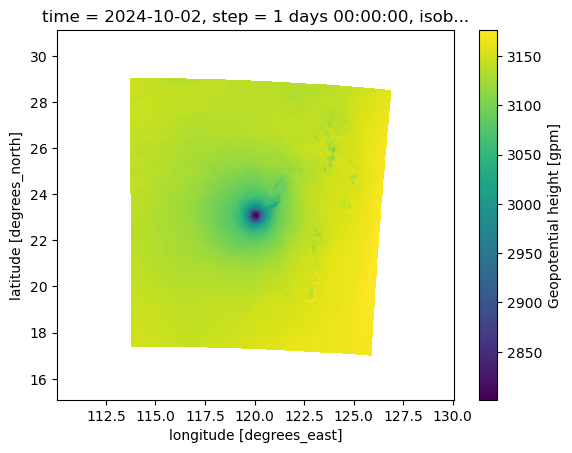

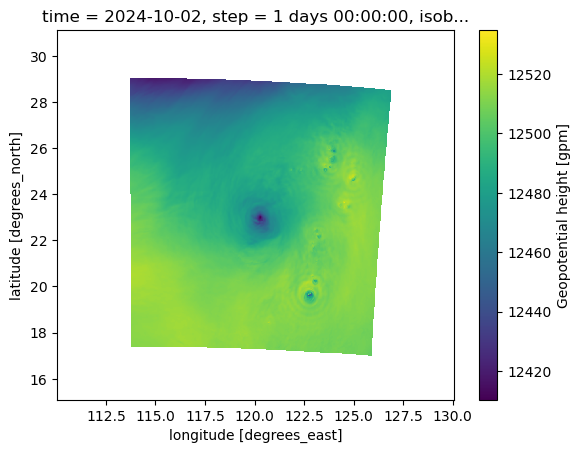

Ignoring index file 'Model_Data/temp_gribs/sfc_temp.grb2.5b7b6.idx' older than GRIB file


1001.0700073242188mb is below the pressure threshold of 1005mb


c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cartopy\mpl\geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


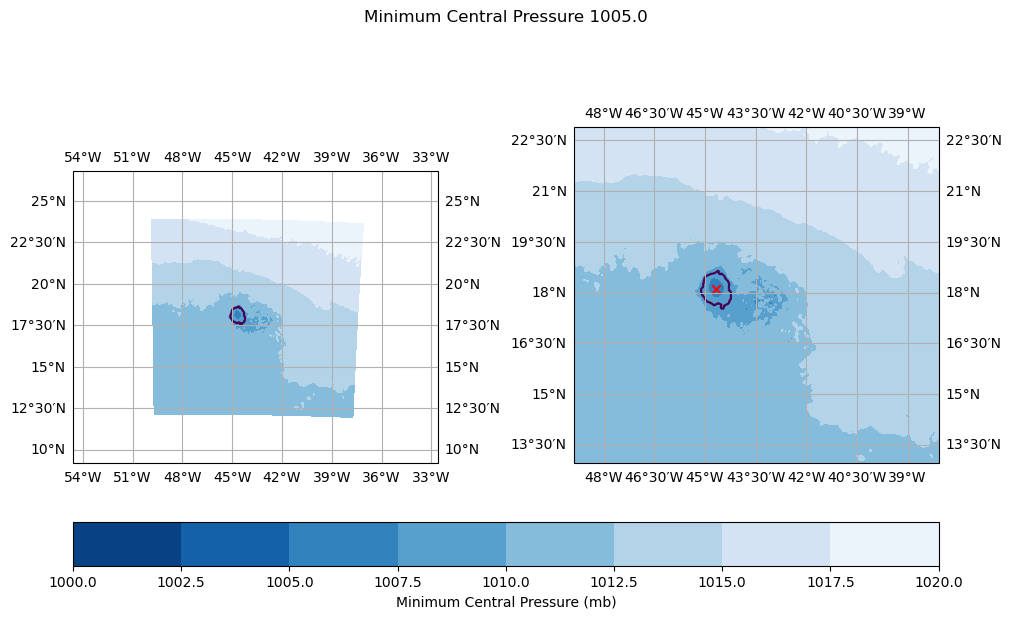

Ignoring index file 'Model_Data/temp_gribs/atm_temp.grib2.5b7b6.idx' older than GRIB file
skipping variable: paramId==3017 shortName='dpt'
Traceback (most recent call last):
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  825.,  800.,
        775.,  750.,  725.,  700.,  675.,  650.,  625.,  600.,  575.,
        550.,  525.,  500.,  475.,  450.,  425.,  400.,  375.,  350.,
        325.,  300.,  275.,  250.,  225.,  200.,  175.,  150.,  125.,
        100.,   70.,   50.

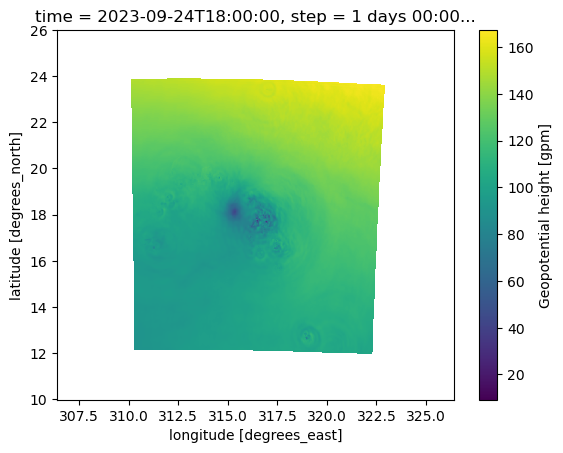

C:\Users\12ian\AppData\Local\Temp\ipykernel_4732\1001496123.py:15: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  land_mask = regionmask.defined_regions.ar6.land.mask(ds_atm.longitude, ds_atm.latitude)


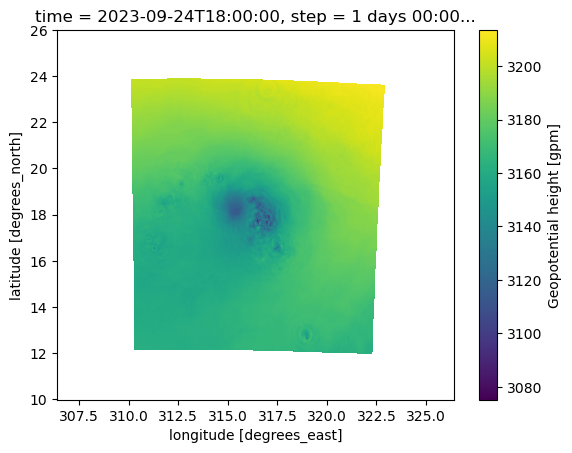

C:\Users\12ian\AppData\Local\Temp\ipykernel_4732\1001496123.py:15: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  land_mask = regionmask.defined_regions.ar6.land.mask(ds_atm.longitude, ds_atm.latitude)


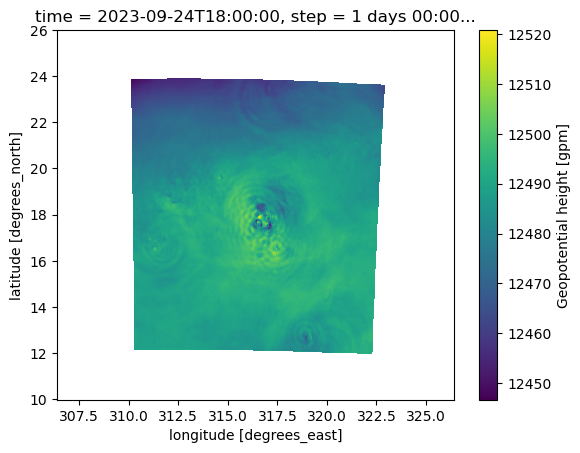

Ignoring index file 'Model_Data/temp_gribs/sfc_temp.grb2.5b7b6.idx' older than GRIB file


959.97998046875mb is below the pressure threshold of 1005mb


c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cartopy\mpl\geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


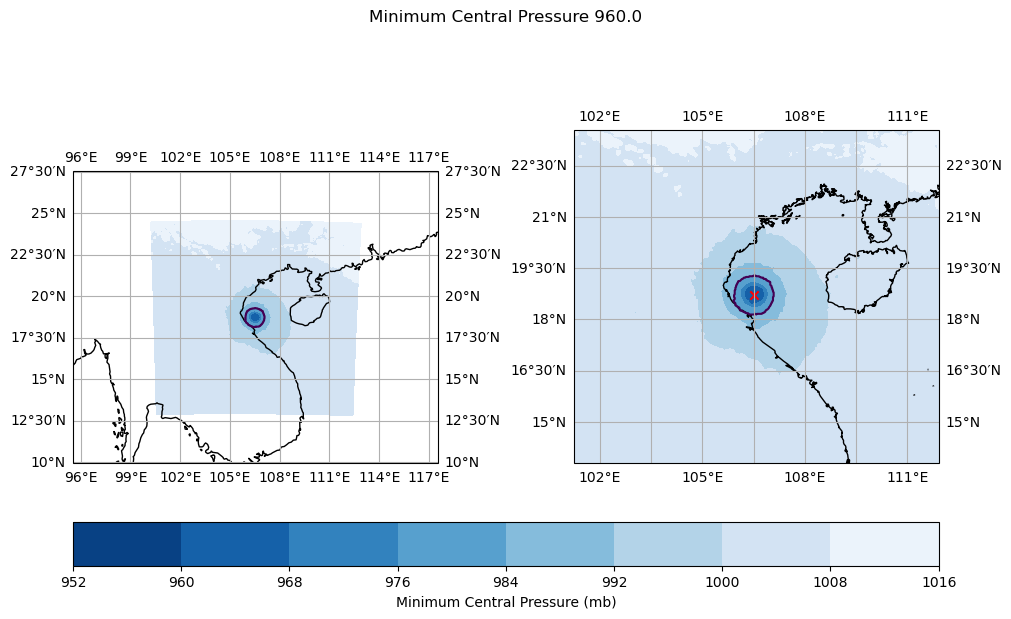

Ignoring index file 'Model_Data/temp_gribs/atm_temp.grib2.5b7b6.idx' older than GRIB file
skipping variable: paramId==3017 shortName='dpt'
Traceback (most recent call last):
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  825.,  800.,
        775.,  750.,  725.,  700.,  675.,  650.,  625.,  600.,  575.,
        550.,  525.,  500.,  475.,  450.,  425.,  400.,  375.,  350.,
        325.,  300.,  275.,  250.,  225.,  200.,  175.,  150.,  125.,
        100.,   70.,   50.

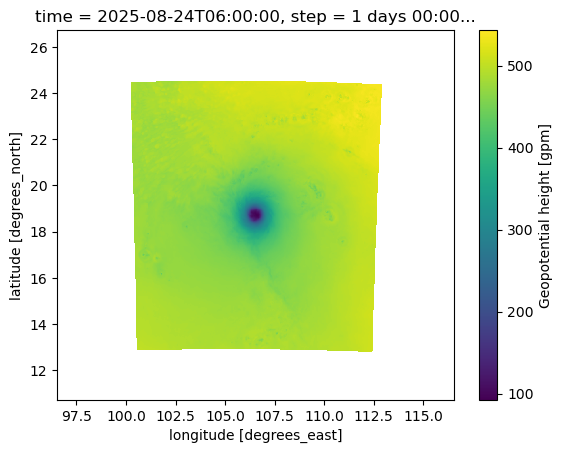

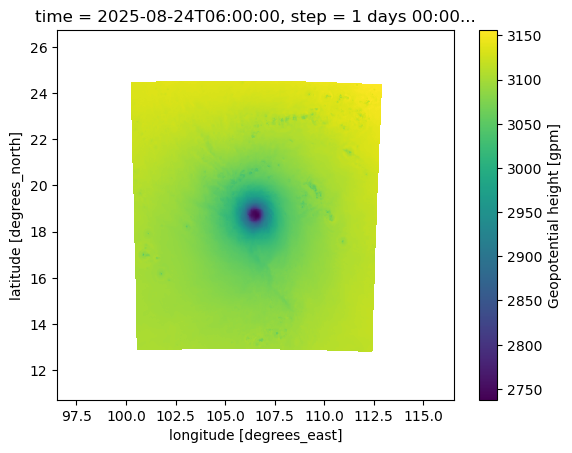

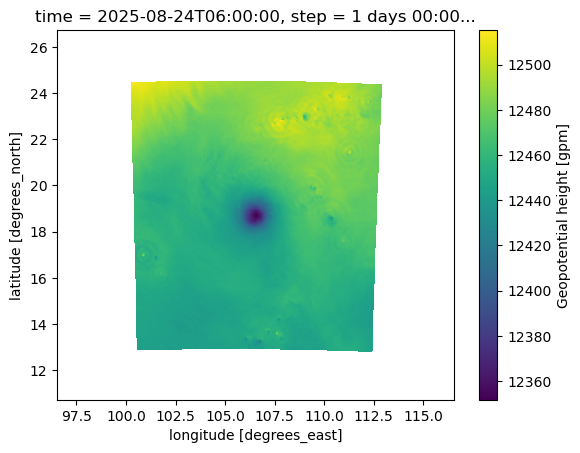

Ignoring index file 'Model_Data/temp_gribs/sfc_temp.grb2.5b7b6.idx' older than GRIB file


992.3699951171875mb is below the pressure threshold of 1005mb


c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cartopy\mpl\geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


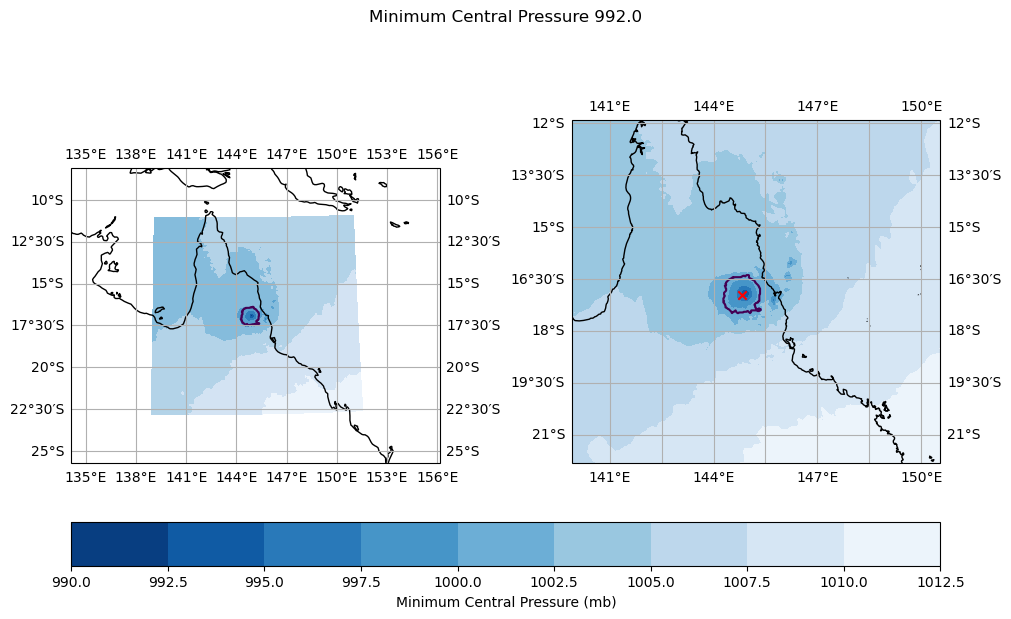

Ignoring index file 'Model_Data/temp_gribs/atm_temp.grib2.5b7b6.idx' older than GRIB file
skipping variable: paramId==3017 shortName='dpt'
Traceback (most recent call last):
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  825.,  800.,
        775.,  750.,  725.,  700.,  675.,  650.,  625.,  600.,  575.,
        550.,  525.,  500.,  475.,  450.,  425.,  400.,  375.,  350.,
        325.,  300.,  275.,  250.,  225.,  200.,  175.,  150.,  125.,
        100.,   70.,   50.

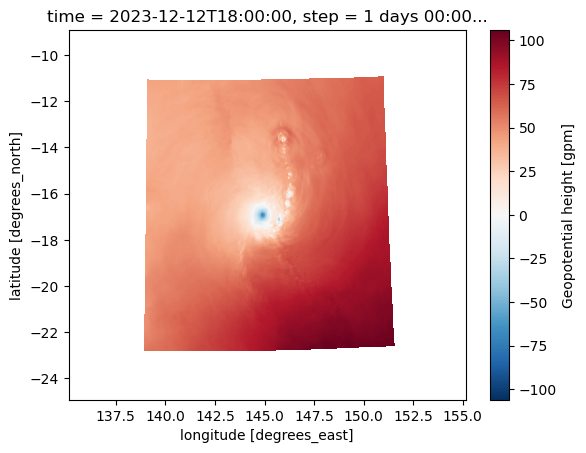

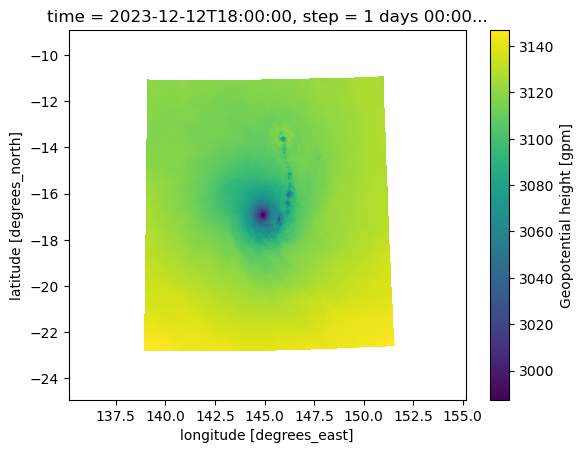

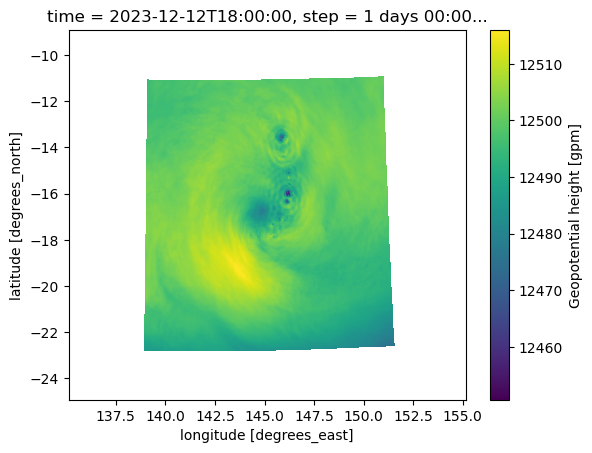

Ignoring index file 'Model_Data/temp_gribs/sfc_temp.grb2.5b7b6.idx' older than GRIB file


1005.6500244140625mb is above the pressure threshold of 1005mb


Ignoring index file 'Model_Data/temp_gribs/sfc_temp.grb2.5b7b6.idx' older than GRIB file


941.1300048828125mb is below the pressure threshold of 1005mb


c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cartopy\mpl\geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


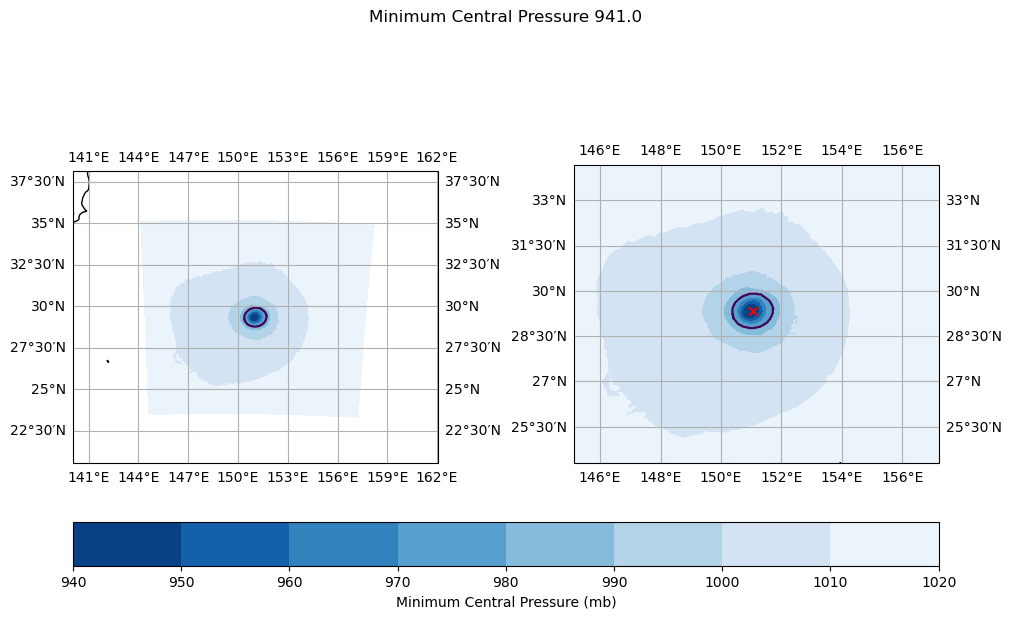

Ignoring index file 'Model_Data/temp_gribs/atm_temp.grib2.5b7b6.idx' older than GRIB file
skipping variable: paramId==3017 shortName='dpt'
Traceback (most recent call last):
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  825.,  800.,
        775.,  750.,  725.,  700.,  675.,  650.,  625.,  600.,  575.,
        550.,  525.,  500.,  475.,  450.,  425.,  400.,  375.,  350.,
        325.,  300.,  275.,  250.,  225.,  200.,  175.,  150.,  125.,
        100.,   70.,   50.

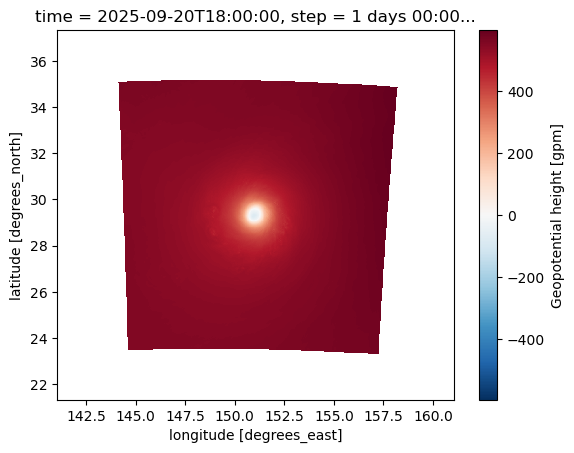

C:\Users\12ian\AppData\Local\Temp\ipykernel_4732\1001496123.py:15: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  land_mask = regionmask.defined_regions.ar6.land.mask(ds_atm.longitude, ds_atm.latitude)


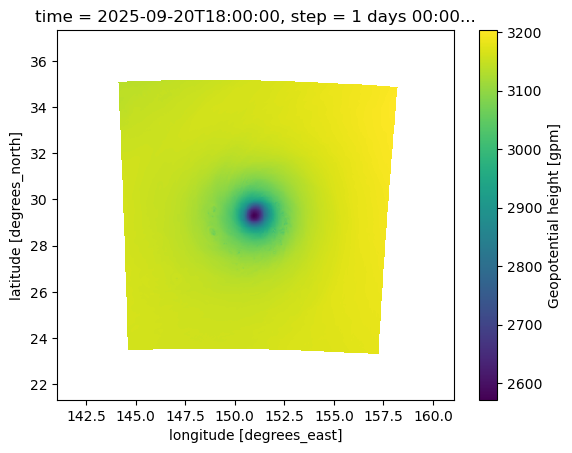

C:\Users\12ian\AppData\Local\Temp\ipykernel_4732\1001496123.py:15: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  land_mask = regionmask.defined_regions.ar6.land.mask(ds_atm.longitude, ds_atm.latitude)


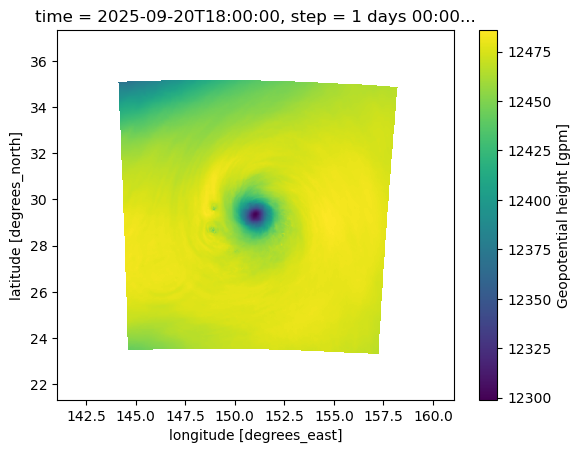

Ignoring index file 'Model_Data/temp_gribs/sfc_temp.grb2.5b7b6.idx' older than GRIB file


1000.6900024414062mb is below the pressure threshold of 1005mb


c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cartopy\mpl\geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


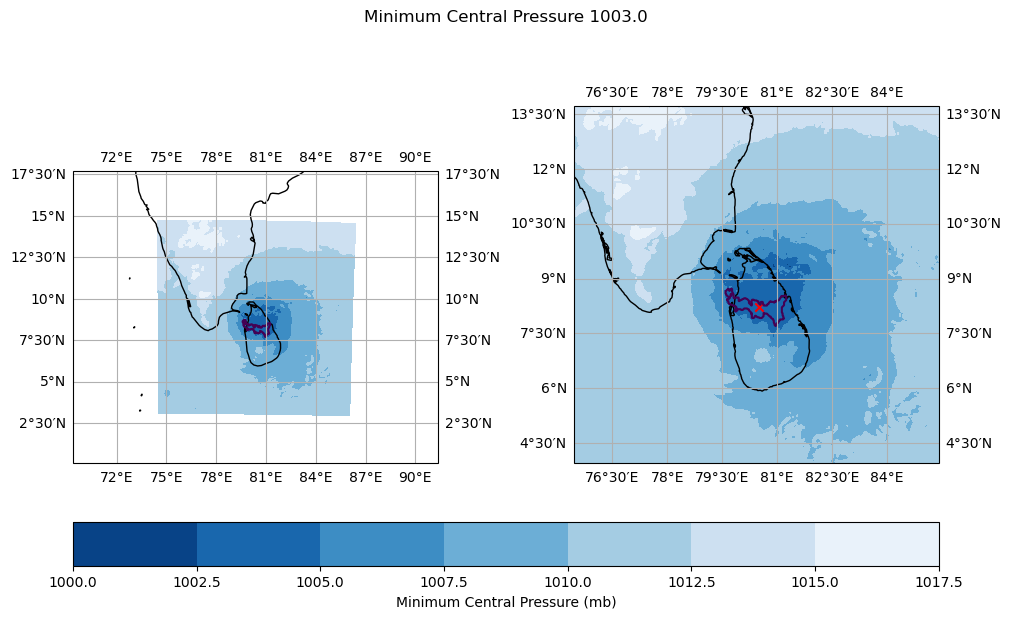

Ignoring index file 'Model_Data/temp_gribs/atm_temp.grib2.5b7b6.idx' older than GRIB file
skipping variable: paramId==3017 shortName='dpt'
Traceback (most recent call last):
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\12ian\anaconda3\envs\MastersProject\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  825.,  800.,
        775.,  750.,  725.,  700.,  675.,  650.,  625.,  600.,  575.,
        550.,  525.,  500.,  475.,  450.,  425.,  400.,  375.,  350.,
        325.,  300.,  275.,  250.,  225.,  200.,  175.,  150.,  125.,
        100.,   70.,   50.

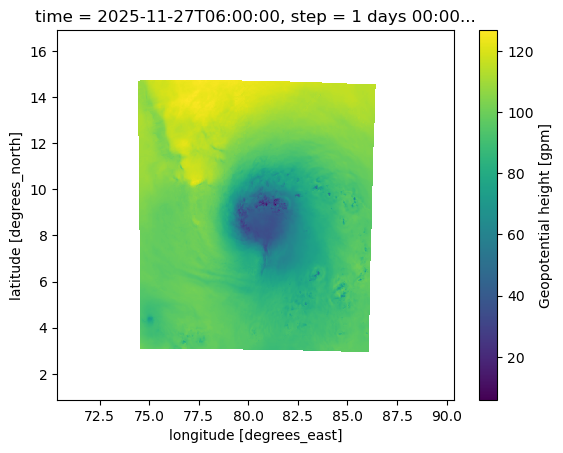

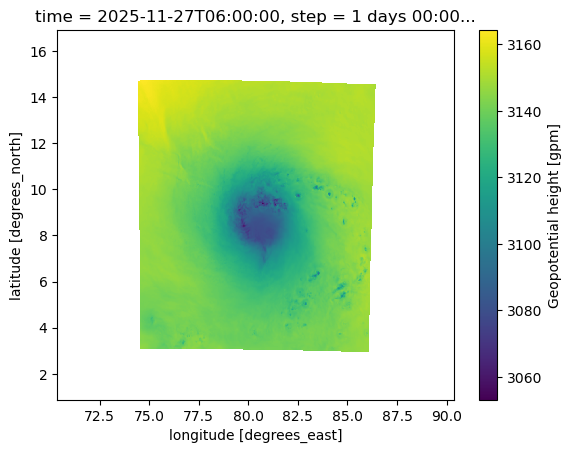

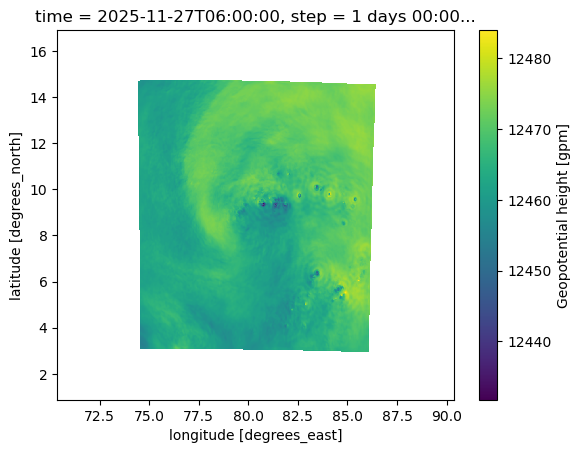

In [30]:
for link in random_links:
    sfc_ds = utils.download_and_open(link, **sfc_args)
    sfc_ds['prmsl'] = sfc_ds['prmsl']/100
    try:
        sfc_center, center_cluster, lat_nest, lon_nest = utils.get_sfc_center(sfc_ds)
    except Exception as e:
        print(e)
        continue
    if not sfc_center:
        continue

    ## Plotting

    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10,8), layout="constrained", subplot_kw = dict(projection = ccrs.PlateCarree()))
    ax[1].contour(lon_nest, lat_nest, center_cluster, color = 'red')
    zoomed_in_cf = ax[1].contourf(lon_nest, lat_nest, sfc_ds['prmsl'].sel(latitude = lat_nest, longitude = lon_nest).values, cmap = 'Blues_r')
    ax[1].scatter(sfc_center['center_lon'], sfc_center['center_lat'], color = 'red', marker = 'x')
    ax[1].add_feature(cfeature.COASTLINE)
    ax[1].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

    ax[0].contourf(sfc_ds.longitude.values, sfc_ds.latitude.values, sfc_ds['prmsl'].values,  cmap = 'Blues_r')
    ax[0].contour(lon_nest, lat_nest, center_cluster)
    ax[0].add_feature(cfeature.COASTLINE)
    ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

    fig.colorbar(zoomed_in_cf, location = 'bottom', ax=[ax[0], ax[1]], label = 'Minimum Central Pressure (mb)')
    rounded_mslp = np.round(sfc_center['mslp'],decimals=0)
    fig.suptitle(f'Minimum Central Pressure {rounded_mslp}',y=0.75)
    plt.show()


    atm_ds = utils.download_and_open(link, **atm_args)
    atm_ds = atm_ds.sel(isobaricInhPa = [sfc_center['mslp'], 700.0, 200.0], method = 'nearest')
    current_level_center = sfc_center
    for level in atm_ds.isobaricInhPa:
        atm_ds_lvl = atm_ds.sel(isobaricInhPa = level)
        current_level_center = get_atm_center(atm_ds_lvl, current_level_center)
        if not current_level_center:
            break
        atm_ds_lvl['gh'].plot()
        plt.show()

In [ ]:
sfc_ds = utils.download_and_open(random_links[0], **sfc_args)
sfc_ds['prmsl'] = sfc_ds['prmsl']/100

In [ ]:
sfc_center = get_sfc_center(sfc_ds)

In [ ]:
atm_ds = utils.download_and_open(random_links[0], **atm_args)
atm_ds = atm_ds.sel(isobaricInhPa = [sfc_center['mslp'].values, 700.0, 200.0], method = 'nearest')